<a href="https://colab.research.google.com/github/Atharva-3954/EDA-Project-Pluto/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introduction

For this project I explored a Netflix dataset with information about all the movies and TV shows on the platform. The file is called `netflix_titles.csv`.

I wanted to answer questions like — does Netflix have more movies or TV shows? Which countries make the most content? What genres are most common? Who is the content mostly made for?

This also gave me a chance to practice data cleaning and making charts. I used Python with pandas, matplotlib, and seaborn.


# 2. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

df = pd.read_csv('netflix_titles.csv')

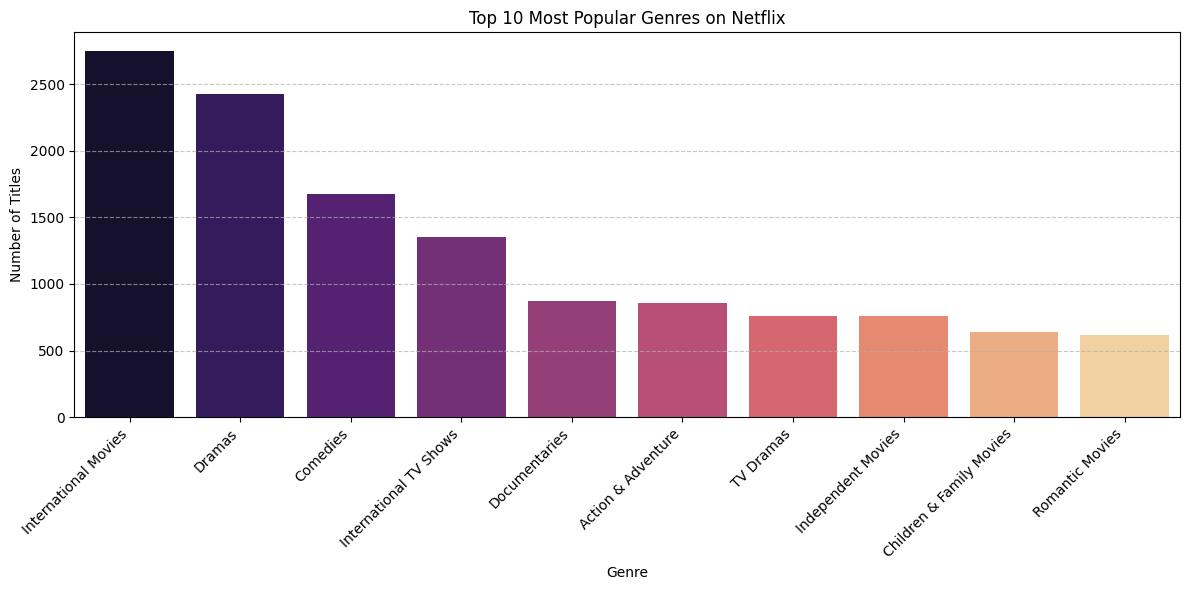

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [2]:
# split 'listed_in' since one title can have multiple genres
genres_df = df['listed_in'].str.split(', ', expand=True)
all_genres = genres_df.stack().value_counts()
top_10_genres = all_genres.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, hue=top_10_genres.index, palette='magma', legend=False)
plt.title('Top 10 Most Popular Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(top_10_genres)

# 3. Data Inspection

Before starting the analysis, I checked the raw data first — number of rows/columns, column names, data types, and missing values. Skipping this usually causes problems later.


In [3]:
# first look at the data
print("First 5 Rows of the Dataset:")
display(df.head())

print("\nShape of the Dataset (rows, columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

First 5 Rows of the Dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Shape of the Dataset (rows, columns):
(8807, 12)

Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [4]:
# check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
# check for duplicates
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [6]:
# summary stats
print("\nNumerical column stats:")
print(df.describe())

print("\nCategorical column stats:")
print(df.describe(include='object'))


Numerical column stats:
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

Categorical column stats:
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   

              country       date_added rating  duration  \
count            7976             8797   8803      8804   
unique            748             1767     17       220   
top     United States  January 1, 2020  TV-MA  1 Season   
freq             2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dra

### Dataset Summary

The Netflix dataset has about 8800 rows and 12 columns. It covers both Movies (~6126 titles) and TV Shows (~2674 titles).

Main columns: `type`, `director`, `country`, `release_year`, `rating`, `duration`, `listed_in` (genres).


In [7]:
# check unique values in key columns
print("\nUnique values in 'type' column:")
print(df['type'].value_counts())

print("\nUnique values in 'rating' column:")
print(df['rating'].value_counts())

# noticed '74 min', '84 min', '66 min' in rating — those are durations, not ratings!

print("\nTop 10 countries:")
print(df['country'].value_counts().head(10))

print("\nUnique genre combinations:")
print(df['listed_in'].nunique())


Unique values in 'type' column:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Unique values in 'rating' column:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Top 10 countries:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Unique genre combinations:
514


# 4. Data Cleaning

After checking the data, I found a few issues to fix before analysis.

Missing values: `director`, `cast`, and `country` had a lot of blanks. `rating` and `date_added` had a few too.

A strange bug: the `rating` column had entries like `'74 min'` and `'84 min'` — those are durations, not age ratings. Someone put them in the wrong column.

Here's what I did:
- Moved the wrong duration values from `rating` to `duration`.
- Dropped rows where `rating` was still missing after fixing.
- Filled missing `country` values with `'Unknown'` so they show up in charts.
- Left `director` and `cast` missing — not needed for my main questions.


### Data Cleaning Decisions

| Issue | Action | Reason |
| :--- | :--- | :--- |
| `rating` had duration strings like '74 min' | Moved them to `duration` column | Wrong column — fixed the data entry error |
| `rating` still had some NaN after fix | Dropped those rows | Rating is important for content analysis |
| Missing values in `country` | Filled with 'Unknown' | Shows up in charts instead of being dropped |
| Missing `director` and `cast` | No action | Not needed for my questions |


In [8]:
# Fix the 'rating' column (move duration values to 'duration' column)
# And fill missing 'country' values with 'Unknown'

# Identify rows where 'rating' contains duration info
duration_ratings_mask = df['rating'].str.contains('min|Season', na=False)

# Move duration strings from 'rating' to 'duration'
df.loc[duration_ratings_mask, 'duration'] = df.loc[duration_ratings_mask, 'rating']

# Set the incorrect 'rating' entries to NaN
df.loc[duration_ratings_mask, 'rating'] = pd.NA

# Fill missing 'country' values with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Check missing values again for 'rating', 'duration', and 'country'
print("\nMissing values in 'rating', 'duration', and 'country' after correction:")
print(df[['rating', 'duration', 'country']].isnull().sum())

# Check unique 'rating' values (make sure durations are gone)
print("\nUnique values in 'rating' column after correction:")
print(df['rating'].value_counts(dropna=False))


Missing values in 'rating', 'duration', and 'country' after correction:
rating      7
duration    0
country     0
dtype: int64

Unique values in 'rating' column after correction:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
<NA>           3
UR             3
Name: count, dtype: int64


#### After fixing the `rating` column:

The `'74 min'` and `'1 Season'` entries are gone from `rating`. Now it only has proper age ratings like TV-MA, TV-14, etc. The `duration` column for those rows is also corrected.


The `director` and `cast` columns still have missing values but I left them — they're not needed for my main questions.

For `rating`, there were a few remaining NaN values after the duration fix, so I dropped those rows since rating matters for the content type analysis.


In [9]:
df = df.dropna(subset=['rating'])
# Check missing 'rating' values
print(f"Number of missing 'rating' values after dropping: {df['rating'].isnull().sum()}")
# Observation: 'rating' column is clean now, no missing values left. Good to go!

Number of missing 'rating' values after dropping: 0


# 5. Exploratory Data Analysis

Here I tried to answer five main questions about the Netflix catalog.


### 5.1 Does Netflix have more Movies or TV Shows?

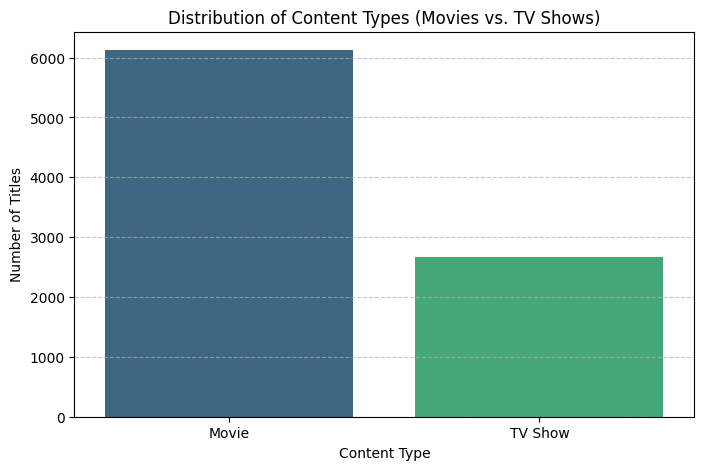

type
Movie      6126
TV Show    2674
Name: count, dtype: int64


In [10]:
# Count the occurrences of each content type
type_counts = df['type'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Content Types (Movies vs. TV Shows)')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(type_counts)

Netflix has 6126 Movies and 2674 TV Shows — so around 70% of the catalog is movies. I expected movies to be more, but not by this much.


### 5.2 How has content on Netflix changed over the years?

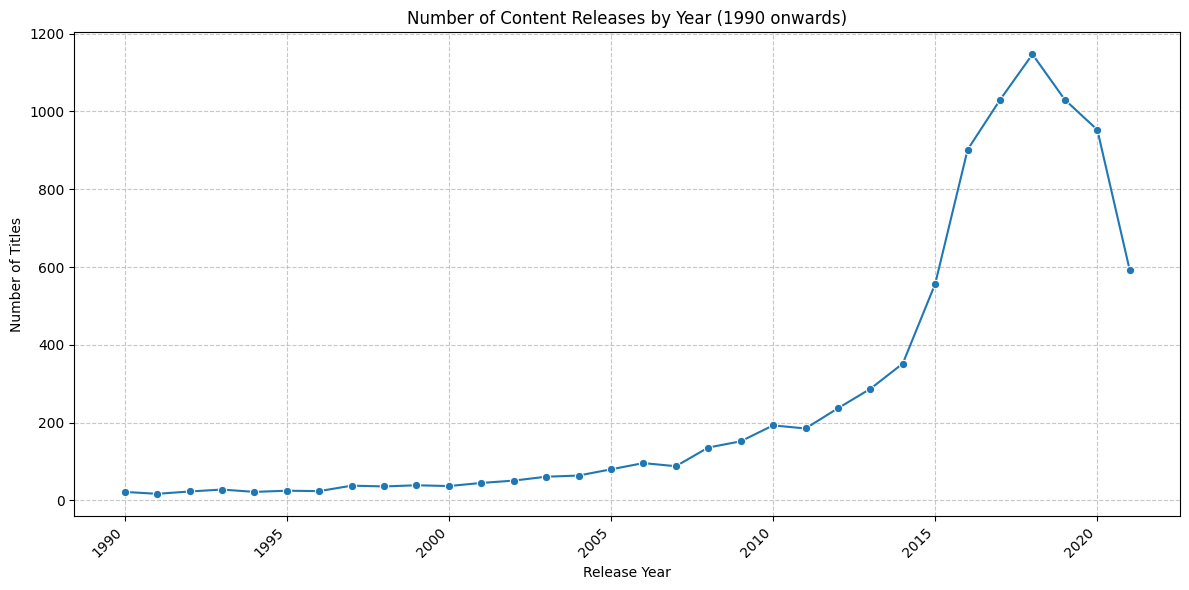

In [11]:
# Count titles by release year and sort them chronologically
release_year_counts = df['release_year'].value_counts().sort_index()

# Filter for years with significant releases (e.g., after 1990 for better visibility)
release_year_counts = release_year_counts[release_year_counts.index >= 1990]

plt.figure(figsize=(12, 6))
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values, marker='o')
plt.title('Number of Content Releases by Year (1990 onwards)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Releases were low before 2010, then shot up and peaked at 1147 titles in 2018. After that it started dropping. One possible reason is that the dataset only goes up to 2021 and there's a lag in data collection for recent years.


### 5.3 Which countries produce the most Netflix content?

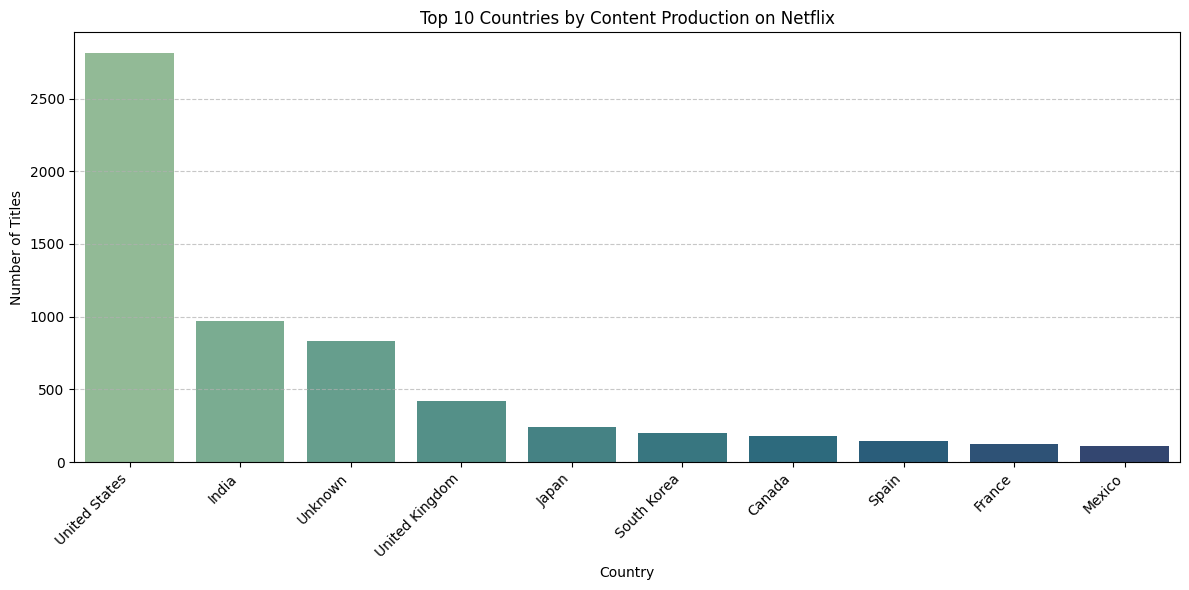

country
United States     2815
India              972
Unknown            830
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [12]:
# Count content by country, excluding NaN values, and get the top 10
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, hue=country_counts.index, palette='crest', legend=False)
plt.title('Top 10 Countries by Content Production on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(country_counts)

The US is way ahead with 2815 titles. India is second with 972 titles, which was a bit unexpected. There's also a big 'Unknown' category (830 titles) due to missing country data.


### 5.4 What are the most common genres?

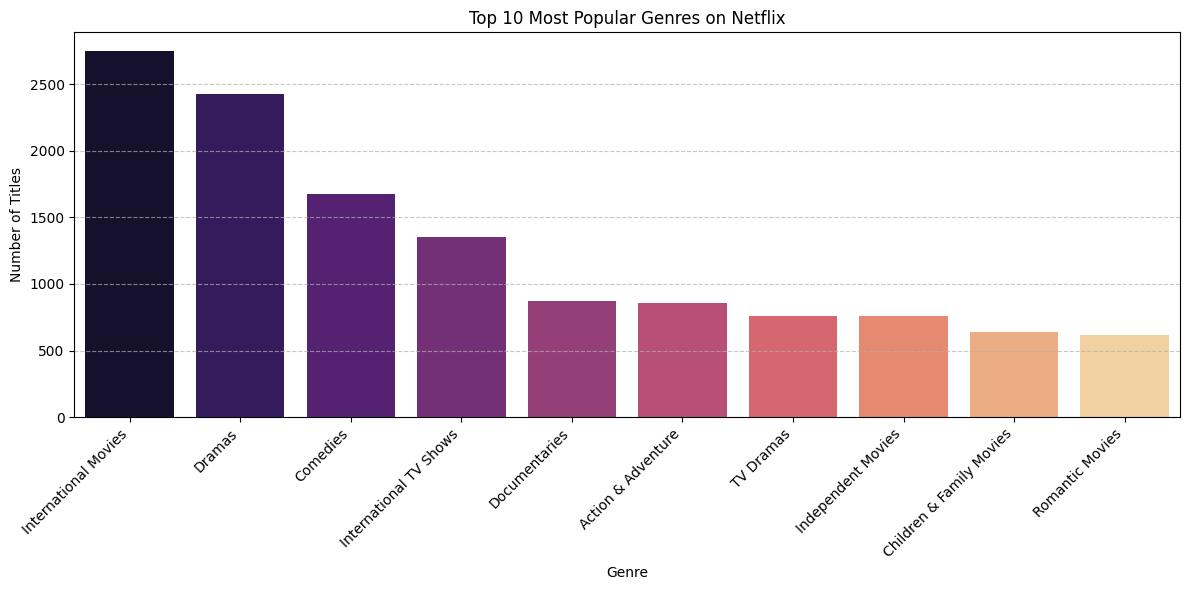

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [13]:
# split genres since one title can have multiple
genres_df = df['listed_in'].str.split(', ', expand=True)
all_genres = genres_df.stack().value_counts()
top_10_genres = all_genres.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, hue=top_10_genres.index, palette='magma', legend=False)
plt.title('Top 10 Most Popular Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(top_10_genres)

'International Movies' is the top genre at 2752 titles, followed by 'Dramas' (2426) and 'Comedies' (1674). Genres had to be split and counted individually since one title can belong to multiple genres.


### 5.5 What are the age ratings of Netflix content?

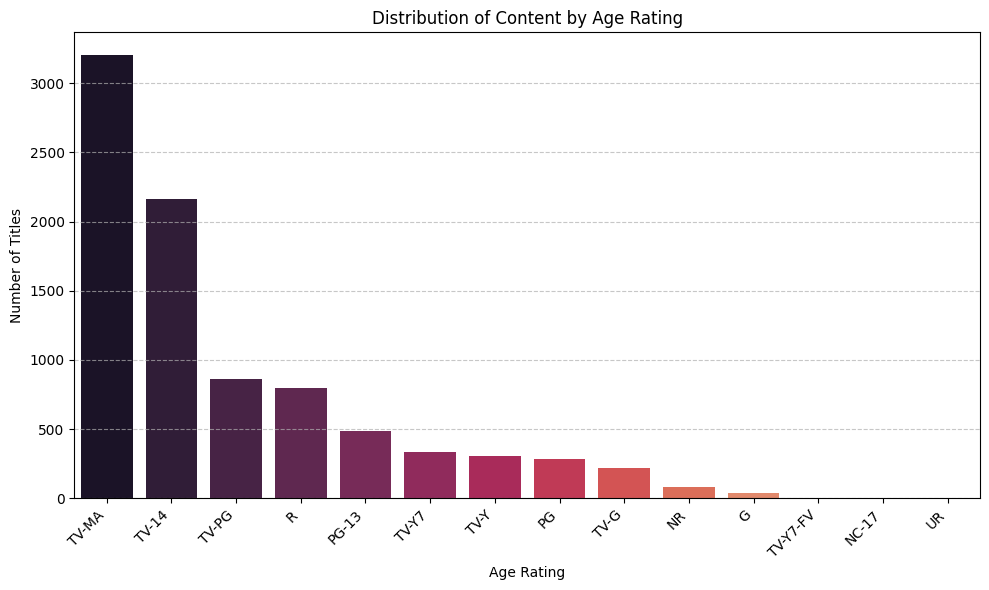

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [14]:
# Count each age rating
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='rocket', legend=False)
plt.title('Distribution of Content by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(rating_counts)

TV-MA is the most common rating with 3207 titles. Most content is for adults or older teens. Kids' content (TV-Y, TV-G) is a much smaller chunk.


## 6. Deeper Questions

After the basic EDA, I wanted to dig a bit more into specific things I was curious about.


### 6.1 How long are movies, and how many seasons do TV shows usually have?

Average movie duration: 99.58 minutes
Average TV show seasons: 1.77 seasons


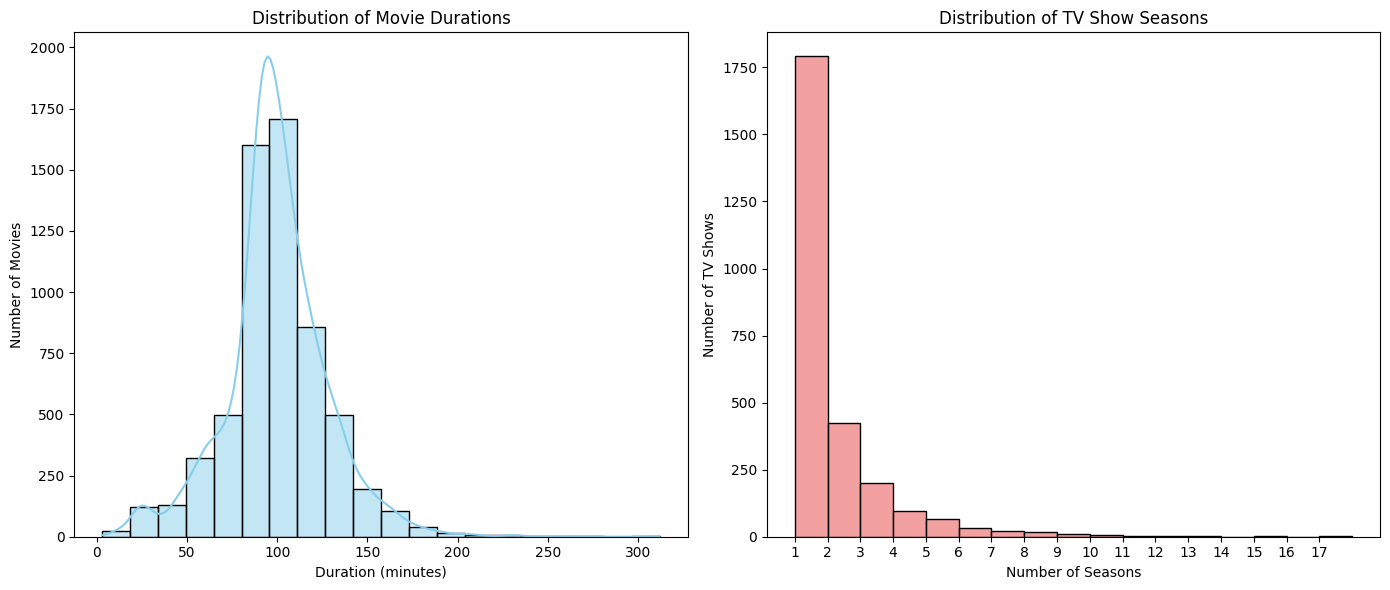

In [15]:
df_cleaned = df.copy()

# extract duration in minutes for movies
movies = df_cleaned[df_cleaned['type'] == 'Movie'].copy()
movies['duration_minutes'] = movies['duration'].str.extract(r'(\d+)', expand=False).astype(float)

# extract number of seasons for TV shows
tv_shows = df_cleaned[df_cleaned['type'] == 'TV Show'].copy()
tv_shows['num_seasons'] = tv_shows['duration'].str.extract(r'(\d+)', expand=False).astype(float)

avg_movie_duration = movies['duration_minutes'].mean()
print(f"Average movie duration: {avg_movie_duration:.2f} minutes")

avg_tv_show_seasons = tv_shows['num_seasons'].mean()
print(f"Average TV show seasons: {avg_tv_show_seasons:.2f} seasons")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(movies['duration_minutes'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.subplot(1, 2, 2)
sns.histplot(tv_shows['num_seasons'].dropna(), bins=range(1, int(tv_shows['num_seasons'].max()) + 2), kde=False, color='lightcoral')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(range(1, int(tv_shows['num_seasons'].max()) + 1))

plt.tight_layout()
plt.show()

Average movie duration is about 99.58 minutes — roughly what you'd expect for a normal film. Average TV show has about 1.77 seasons. Most shows in the histogram had just 1 season, which I found surprising.


### 6.2 Which directors have the most titles on Netflix?

Top 10 Directors by Number of Titles:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          11
Name: count, dtype: int64

Content types for top director (Rajiv Chilaka):
type
Movie    19
Name: count, dtype: int64


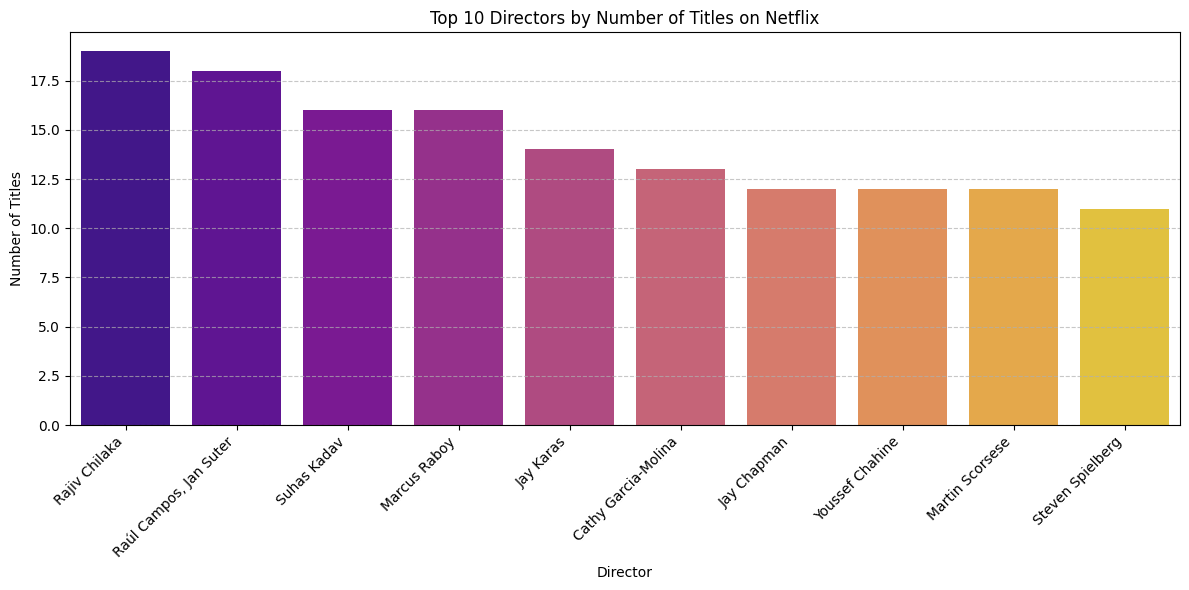

In [16]:
# top directors by number of titles
director_counts = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

print("Top 10 Directors by Number of Titles:")
print(director_counts)

top_director = director_counts.index[0]
top_director_content = df[df['director'] == top_director]['type'].value_counts()
print(f"\nContent types for top director ({top_director}):")
print(top_director_content)

plt.figure(figsize=(12, 6))
sns.barplot(x=director_counts.index, y=director_counts.values, hue=director_counts.index, palette='plasma', legend=False)
plt.title('Top 10 Directors by Number of Titles on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Rajiv Chilaka has the most — 19 titles. I'd never heard of him before. Turns out he makes animated Indian kids' content. A few other directors also have 15+ titles each.


### 6.3 Has the Movie vs. TV Show mix changed over the years?

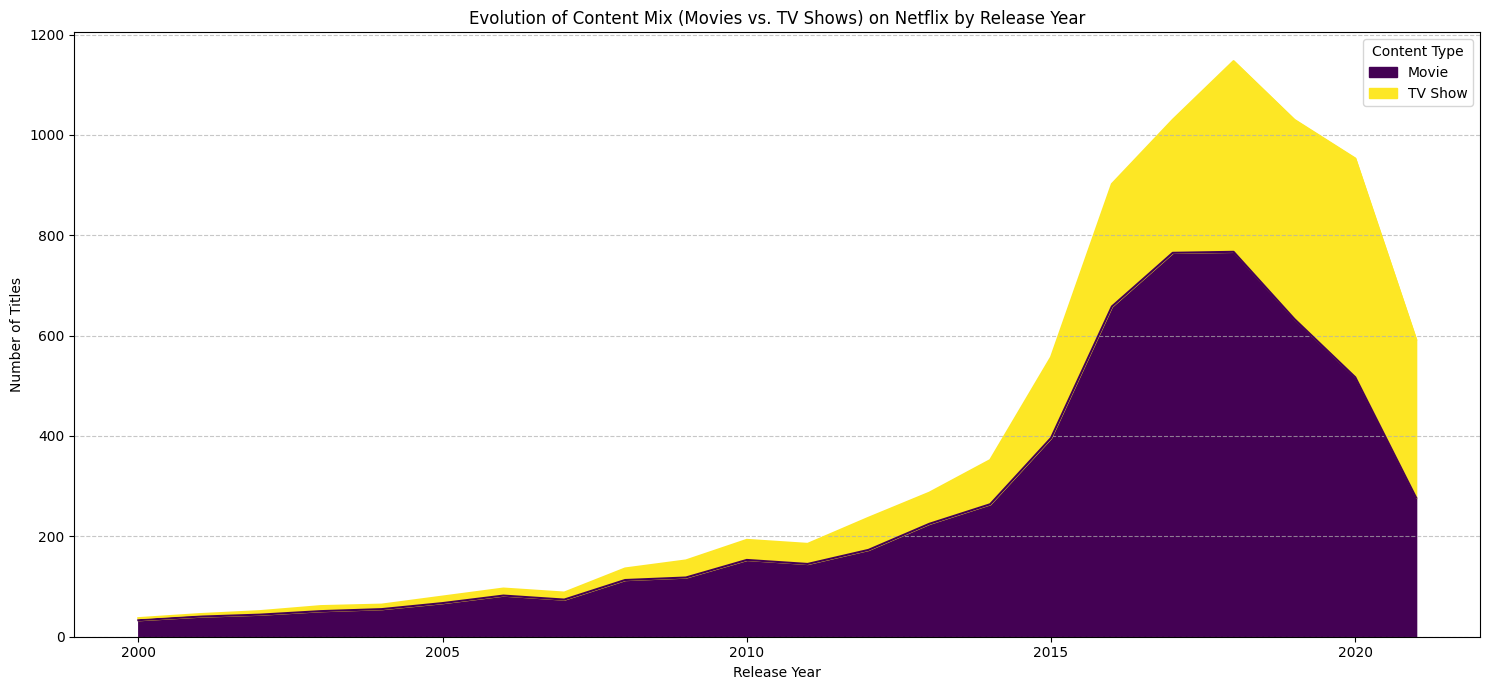

In [17]:
# Group by release year and content type, then count titles
content_mix_over_time = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# Consider years with significant activity for clearer trends (e.g., from 2000 onwards)
content_mix_over_time = content_mix_over_time[content_mix_over_time.index >= 2000]

# Plotting the trend
# No explicit plt.figure() call here, as DataFrame.plot() will create one with figsize
content_mix_over_time.plot(kind='area', stacked=True, colormap='viridis', figsize=(15, 7))
plt.title('Evolution of Content Mix (Movies vs. TV Shows) on Netflix by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

Movies were always more than TV shows, but the gap has been closing. In 2021, TV show releases (315) actually crossed movie releases (277) for the first time in the dataset.


### 6.4 Are genres different between Movies and TV Shows?

Top 10 Genres in Movies:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

Top 10 Genres in TV Shows:
listed_in
International TV Shows    1350
TV Dramas                  763
TV Comedies                580
Crime TV Shows             470
Kids' TV                   450
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               175
Name: count, dtype: int64


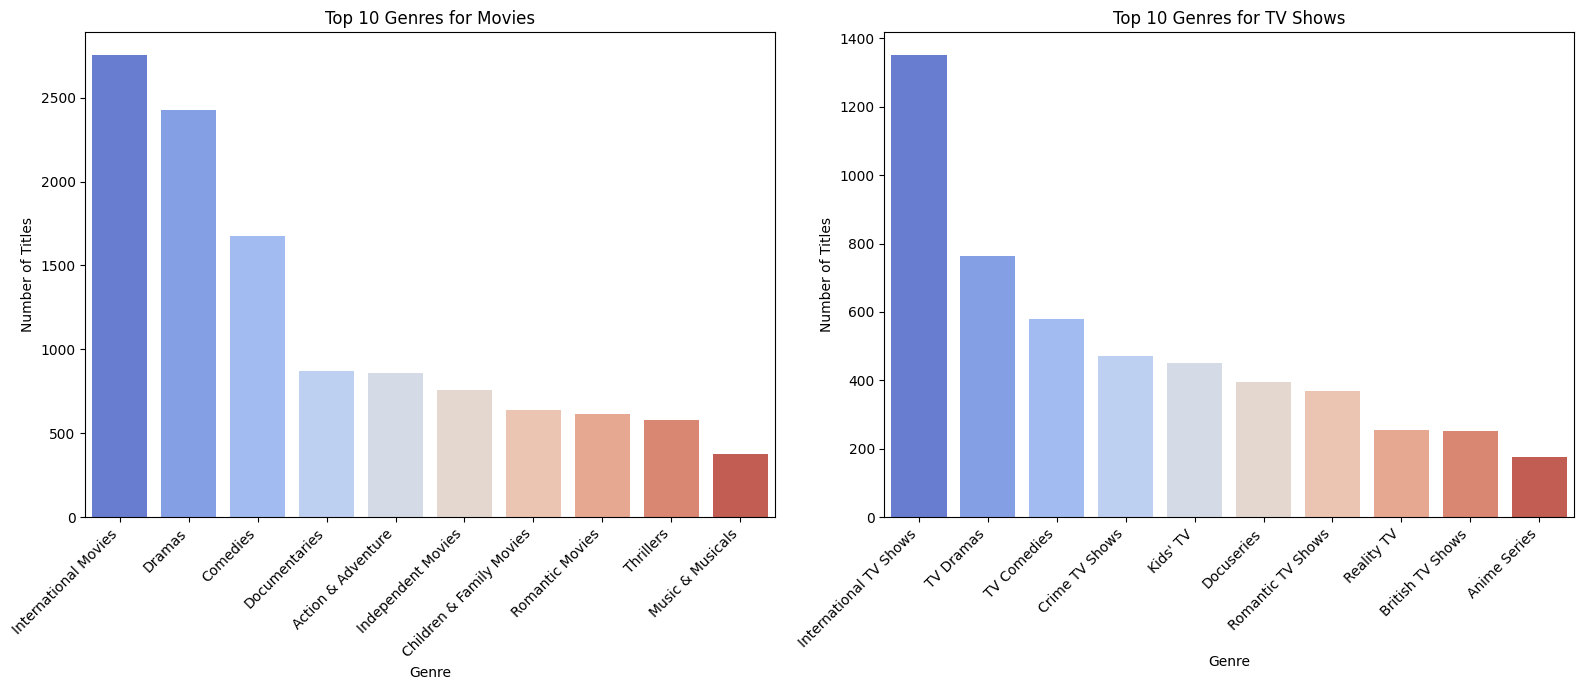

In [18]:
# Prepare data for genre analysis by type

# Get genres for movies using a more efficient method
movie_genres_series = df[df['type'] == 'Movie']['listed_in'].str.split(', ').explode().value_counts().head(10)

# Get genres for TV shows using a more efficient method
tv_show_genres_series = df[df['type'] == 'TV Show']['listed_in'].str.split(', ').explode().value_counts().head(10)

print("Top 10 Genres in Movies:")
print(movie_genres_series)
print("\nTop 10 Genres in TV Shows:")
print(tv_show_genres_series)

# Plotting side-by-side bar charts
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.barplot(x=movie_genres_series.index, y=movie_genres_series.values, hue=movie_genres_series.index, palette='coolwarm', legend=False)
plt.title('Top 10 Genres for Movies')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=tv_show_genres_series.index, y=tv_show_genres_series.values, hue=tv_show_genres_series.index, palette='coolwarm', legend=False)
plt.title('Top 10 Genres for TV Shows')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The top genres are similar for both — International, Drama, and Comedy dominate. The main difference is just the label (e.g., 'International Movies' vs. 'International TV Shows').


### 6.5 Which year had the most new content added?

In [19]:
# Group by release_year and type, get total per year
yearly_totals = df.groupby('release_year')['type'].value_counts().unstack(fill_value=0)
yearly_totals['Total'] = yearly_totals.sum(axis=1)

# Filter for years 2000 onwards for readability
yearly_totals_filtered = yearly_totals[yearly_totals.index >= 2000]

# Find the peak year
peak_year = yearly_totals_filtered['Total'].idxmax()
peak_count = yearly_totals_filtered['Total'].max()
print(f"Peak year: {peak_year} with {peak_count} titles added")

# Show top 5 years
print("\nTop 5 years by total titles:")
print(yearly_totals_filtered['Total'].sort_values(ascending=False).head())

Peak year: 2018 with 1147 titles added

Top 5 years by total titles:
release_year
2018    1147
2017    1030
2019    1030
2020     953
2016     902
Name: Total, dtype: int64


2018 had the highest number with 1147 titles total — 767 Movies and 380 TV Shows. This was clearly Netflix's biggest content push year.


# 6. Additional Visualizations

A few more charts I made to explore the data from different angles.


### Content Mix Over Time (Movies vs. TV Shows)

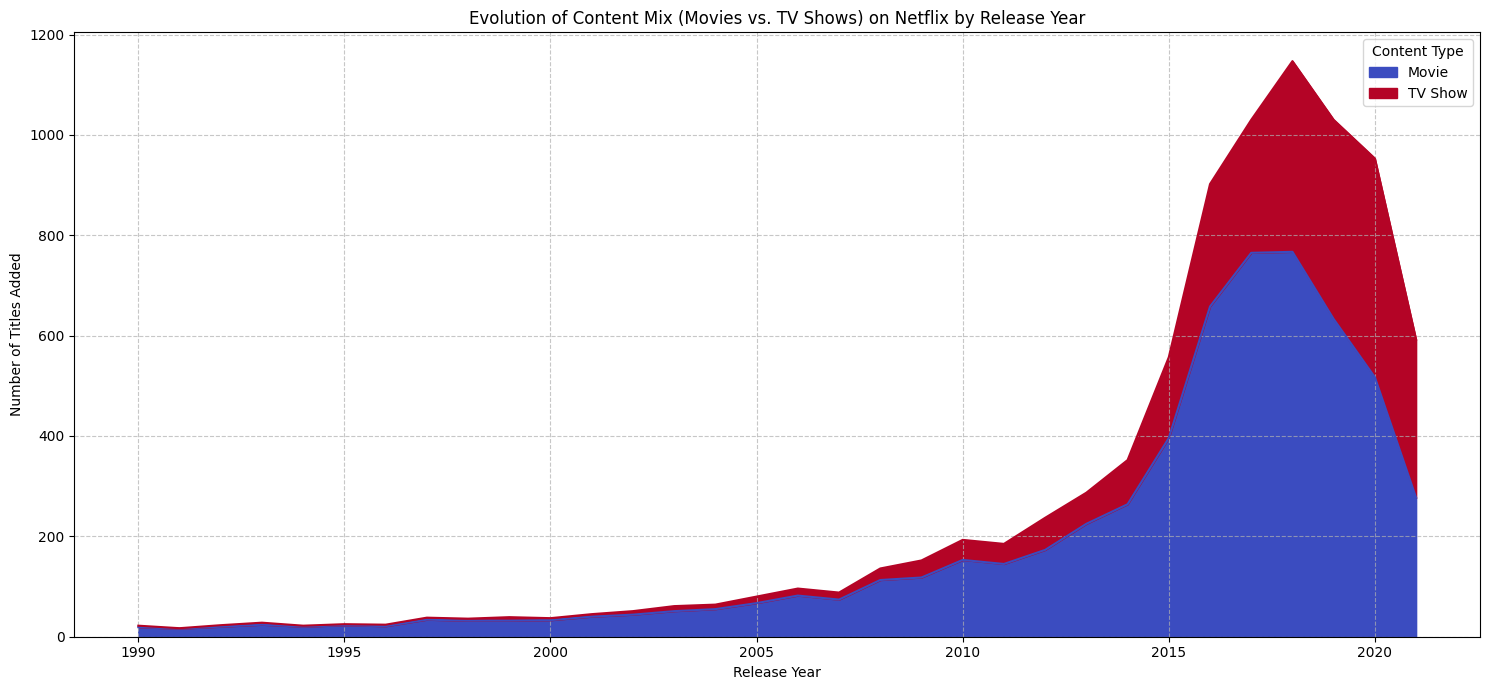

In [20]:
# Group by release year and content type, then count titles
content_mix_over_time = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# Consider years with significant activity for clearer trends (e.g., from 1990 onwards)
content_mix_over_time = content_mix_over_time[content_mix_over_time.index >= 1990]

# Plotting the trend as a stacked area chart
# Directly use DataFrame.plot to create the figure and axes
ax = content_mix_over_time.plot(kind='area', stacked=True, colormap='coolwarm', figsize=(15, 7))
ax.set_title('Evolution of Content Mix (Movies vs. TV Shows) on Netflix by Release Year')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles Added')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='Content Type')
plt.tight_layout()
plt.show()

The stacked area chart shows movies always making up the bigger portion, but TV shows growing steadily. In 2021, TV shows briefly overtook movies in new additions.


### Top 10 Countries by Content Type

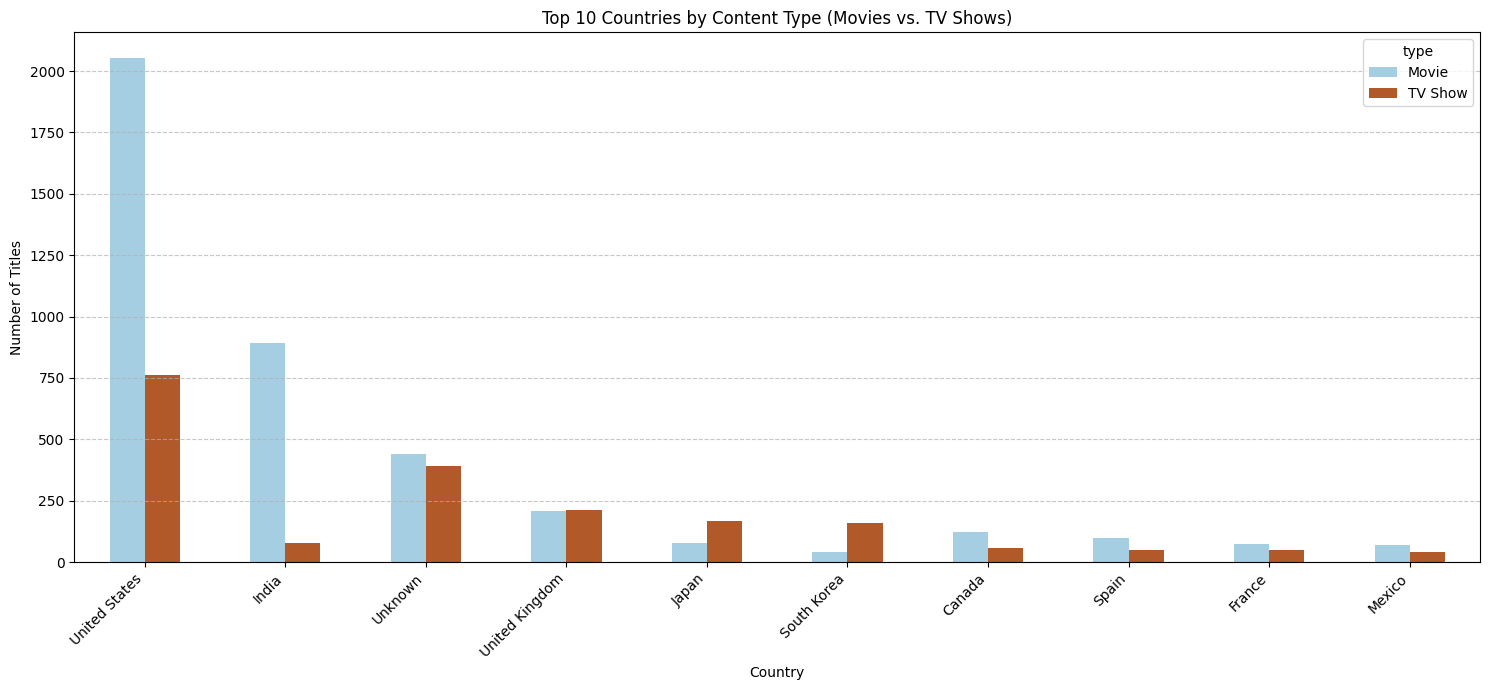

In [21]:
# To analyze top countries by content type, we first need to handle the 'country' column for multiple entries.
# However, for a simpler bar chart focusing on primary country, we'll use the original 'country' column.
# Missing 'country' values should already be filled with 'Unknown' in the main cleaning section.

# Group by country and content type, then count titles
country_type_counts = df.groupby(['country', 'type']).size().unstack(fill_value=0)

# Get top N countries overall (or by specific content type dominance)
# For simplicity, let's take the top 10 countries based on total content
top_countries = df['country'].value_counts().head(10).index

# Filter the grouped data for these top countries
top_country_type_counts = country_type_counts.loc[top_countries]

# Plotting grouped bar chart
top_country_type_counts.plot(kind='bar', figsize=(15, 7), colormap='Paired')
plt.title('Top 10 Countries by Content Type (Movies vs. TV Shows)')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

US is strong in both movies and TV shows. India contributes mostly movies. Japan and South Korea show more TV shows relative to movies compared to other countries.


### Age Rating Distribution by Content Type

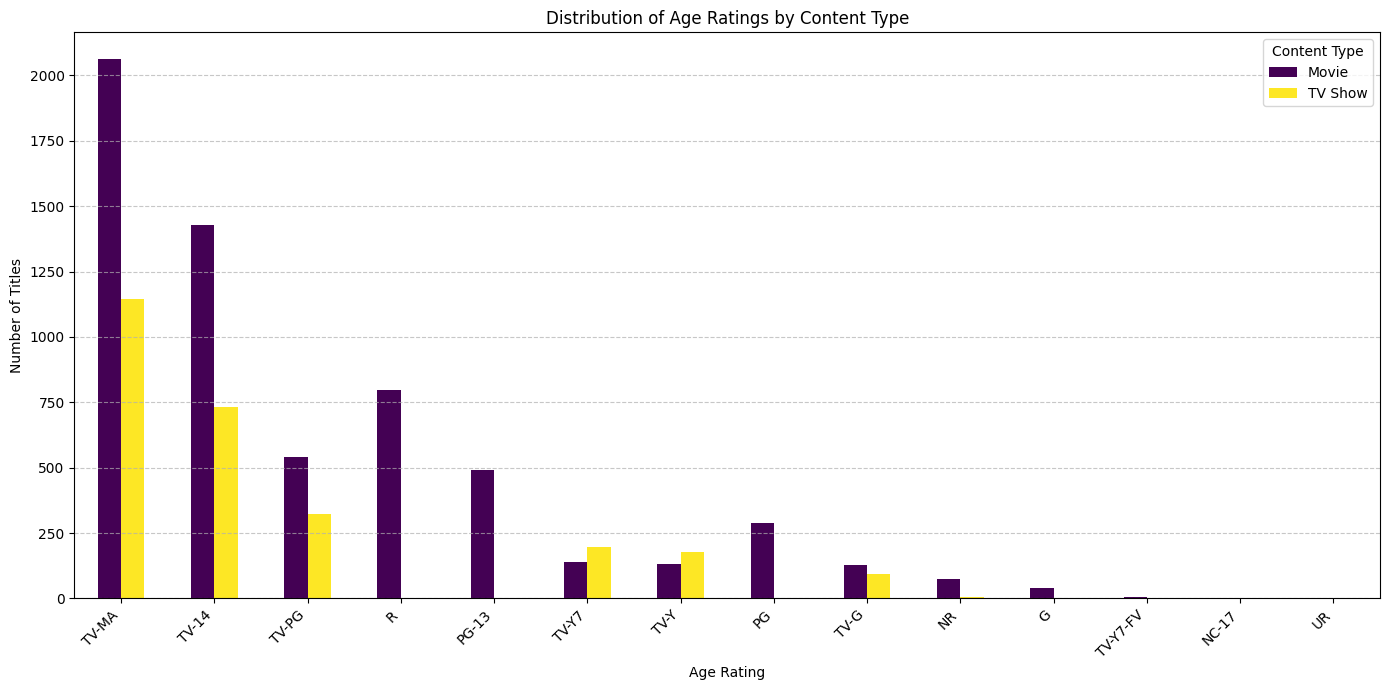

In [22]:
# Group by rating and content type, then count titles
rating_by_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)

# Sort ratings if there's a logical order (e.g., from youngest to oldest, if interpretable)
# For this general purpose, we'll sort by total count descending.
rating_by_type['Total'] = rating_by_type['Movie'] + rating_by_type['TV Show']
rating_by_type = rating_by_type.sort_values(by='Total', ascending=False).drop('Total', axis=1)

# Plotting grouped bar chart
rating_by_type.plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title('Distribution of Age Ratings by Content Type')
plt.xlabel('Age Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

TV-MA dominates for both movies and TV shows. There's a decent number of R-rated movies too. Kids' content (TV-Y, TV-G) is pretty small across both categories.


### Scatter Plot: Release Year vs. Movie Duration

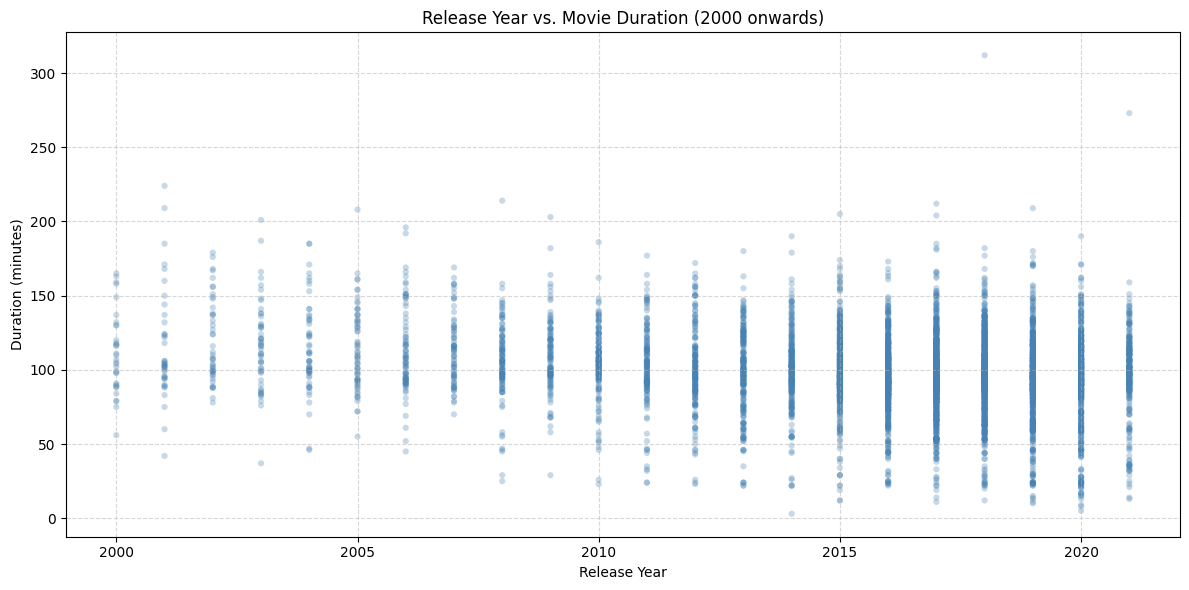

In [23]:
# Filter only movies and extract duration as a number
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_mins'] = movies_df['duration'].str.extract(r'(\d+)').astype(float)

# Only use recent years for a cleaner plot
movies_recent = movies_df[movies_df['release_year'] >= 2000].dropna(subset=['duration_mins'])

plt.figure(figsize=(12, 6))
plt.scatter(movies_recent['release_year'], movies_recent['duration_mins'],
            alpha=0.3, color='steelblue', edgecolors='none', s=20)
plt.title('Release Year vs. Movie Duration (2000 onwards)')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

No clear trend — movie lengths haven't changed much from 2000 to 2021. Most movies cluster around 80–120 minutes regardless of release year.


### Pie Chart: Movies vs. TV Shows

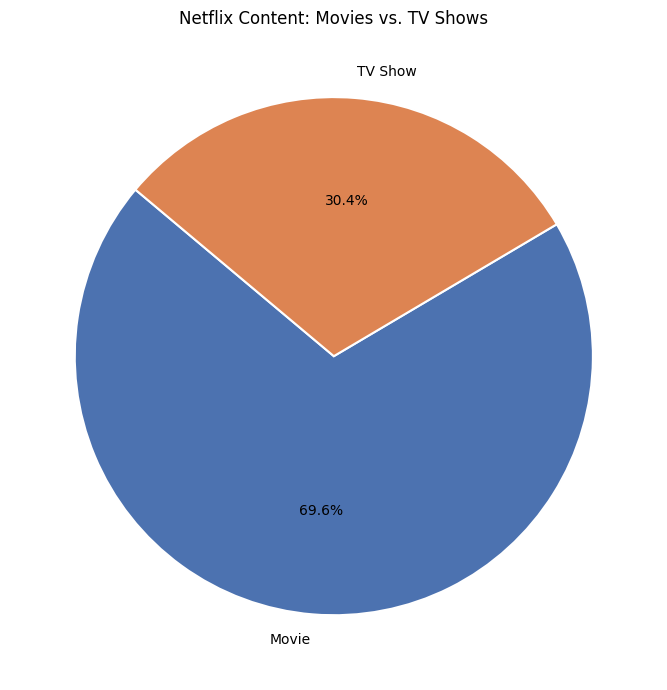

type
Movie      6126
TV Show    2674
Name: count, dtype: int64


In [24]:
# Count movies vs TV shows
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values,
        labels=type_counts.index,
        autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'],
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Netflix Content: Movies vs. TV Shows')
plt.tight_layout()
plt.show()

print(type_counts)

Movies are about 69.6% of the catalog (6126 titles). TV Shows are the remaining 30.4% (2674 titles). Despite Netflix being known for its shows, movies make up the majority by count.


### Heatmap: Content by Country and Type (Top 10 Countries)

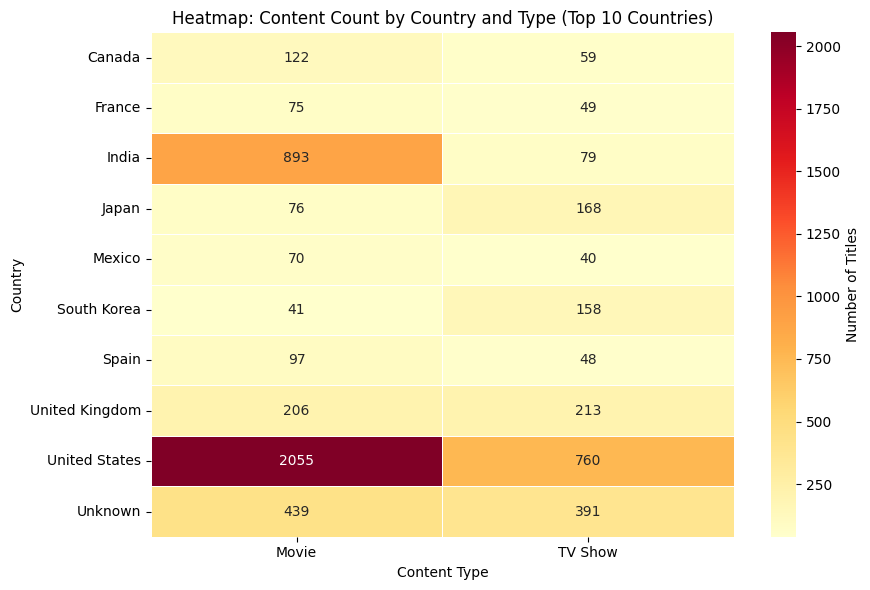

In [25]:
# Get top 10 countries
top_10_countries = df['country'].value_counts().head(10).index.tolist()

# Filter and pivot
heatmap_data = df[df['country'].isin(top_10_countries)].groupby(['country', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(9, 6))
sns.heatmap(heatmap_data,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Number of Titles'})
plt.title('Heatmap: Content Count by Country and Type (Top 10 Countries)')
plt.xlabel('Content Type')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

The heatmap confirms that the US leads in both categories. India is heavy on movies but light on TV shows. Japan and South Korea are the opposite — more TV shows relative to movies.


# 7. Insights

## What I Found

**1. Netflix is mostly a movie platform**  
About 70% of the catalog is movies (6,126 vs. 2,674 TV shows). Bigger difference than I expected.

**2. Most content was added between 2016–2019**  
Releases ramped up from 2014, peaked in 2018, then slowed down. That was clearly their big content push phase.

**3. US dominates, but India is second**  
The US is way ahead. India in second was a bit unexpected — mostly through movies. Shows Netflix is targeting that market.

**4. Most content is for adults**  
TV-MA is the top rating across both types. Family-friendly content is a small fraction.

**5. TV shows are short-lived**  
Average is under 2 seasons. Most shows only ran for 1 season — could be limited series or early cancellations.

**6. Drama and International dominate genres**  
Both for movies and TV shows, these two genres consistently come out on top.

**7. Movie lengths haven't changed**  
Still mostly 80–120 minutes, no matter what year they were released.

**8. Rajiv Chilaka has 19 Netflix titles**  
Totally unexpected. He makes animated Indian kids' content — never heard of him before this project.

**Most surprising finding:** I thought TV shows would average 3–4 seasons, but the data showed most have just 1. I'm not sure if they're designed as limited series or just got cancelled, but I didn't expect that at all.


# 8. Conclusion

## What I Learned

The `rating` column bug was the most interesting part — finding `'74 min'` in a column that should only have age ratings was something I wouldn't have noticed without actually checking unique values. That taught me to always inspect columns carefully.

Splitting the `listed_in` column for genre counting also took some trial and error since one title can belong to multiple genres.

**Tools used:** pandas for data loading and cleaning, matplotlib and seaborn for all charts.

**What the data showed:**  
Netflix's catalog is mostly movies and mostly aimed at adults. The US is the biggest contributor but India is a strong second. Most TV shows don't last more than one season. Netflix had its biggest content push around 2016–2019.

If I continued this project, I'd try to add IMDb ratings or Rotten Tomatoes scores to see not just how much content there is, but how well-received it actually is.
